In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('default')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('../data/processed/clean/combined_individual_events.csv')

print(f"Shape: {df.shape}\n")

df.head()

Shape: (345, 17)



,year,event_name,stroke,gender,distance,meet,source_file,winning_time_sec,winning_time_format,a_final_cutoff_sec,a_final_cutoff_format,b_final_cutoff_sec,b_final_cutoff_format,c_final_cutoff_sec,c_final_cutoff_format,total_swimmers,results
0,2002,100_Backstroke,Backstroke,Men,100,2002_Nescac_Msd_Results,2002_NESCAC_MSD_Results.txt,51.45,51.45,54.94,54.94,56.16,56.16,NaN,NaN,23,"[{'name': 'Schwenker, Eric', 'yr': 'SR', 'scho..."
1,2002,100_Breaststroke,Breaststroke,Men,100,2002_Nescac_Msd_Results,2002_NESCAC_MSD_Results.txt,56.98,56.98,59.83,59.83,61.58,1:01.58,63.14,1:03.14,35,"[{'name': 'Eck, Jonathan', 'yr': 'JR', 'school..."
2,2002,100_Butterfly,Butterfly,Men,100,2002_Nescac_Msd_Results,2002_NESCAC_MSD_Results.txt,50.70,50.70,53.04,53.04,54.46,54.46,56.05,56.05,28,"[{'name': 'Stuntz, Grayson', 'yr': 'SR', 'scho..."
3,2002,100_Freestyle,Freestyle,Men,100,2002_Nescac_Msd_Results,2002_NESCAC_MSD_Results.txt,45.83,45.83,48.14,48.14,48.79,48.79,49.54,49.54,45,"[{'name': 'Walendziak, Nick', 'yr': 'SO', 'sch..."
4,2002,200_Backstroke,Backstroke,Men,200,2002_Nescac_Msd_Results,2002_NESCAC_MSD_Results.txt,111.13,1:51.13,118.61,1:58.61,121.44,2:01.44,135.04,2:15.04,24,"[{'name': 'Schwenker, Eric', 'yr': 'SR', 'scho..."


In [ ]:
cutoff_data = []
for _, row in df.iterrows():
    if pd.notna(row['a_final_cutoff_sec']):
        cutoff_data.append({'year': row['year'], 'stroke': row['stroke'], 'gender': row['gender'], 'distance': row['distance'], 'final_type': 'A', 'cutoff_sec': row['a_final_cutoff_sec']})
    if pd.notna(row['b_final_cutoff_sec']):
        cutoff_data.append({'year': row['year'], 'stroke': row['stroke'], 'gender': row['gender'], 'distance': row['distance'], 'final_type': 'B', 'cutoff_sec': row['b_final_cutoff_sec']})
    if pd.notna(row['c_final_cutoff_sec']):
        cutoff_data.append({'year': row['year'], 'stroke': row['stroke'], 'gender': row['gender'], 'distance': row['distance'], 'final_type': 'C', 'cutoff_sec': row['c_final_cutoff_sec']})

cutoff_df = pd.DataFrame(cutoff_data)
print(f"Processed dataset shape: {cutoff_df.shape}")
print("\nSample of processed data:")
cutoff_df.head()

Processed dataset shape: (1022, 6)

Sample of processed data:


,year,stroke,gender,distance,final_type,cutoff_sec
0,2002,Backstroke,Men,100,A,54.94
1,2002,Backstroke,Men,100,B,56.16
2,2002,Breaststroke,Men,100,A,59.83
3,2002,Breaststroke,Men,100,B,61.58
4,2002,Breaststroke,Men,100,C,63.14


In [8]:
print("Final type distribution:")
print(cutoff_df['final_type'].value_counts())
print("\nCutoff time statistics:")
print(cutoff_df['cutoff_sec'].describe())
# Check for any outliers
Q1 = cutoff_df['cutoff_sec'].quantile(0.25)
Q3 = cutoff_df['cutoff_sec'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = cutoff_df[(cutoff_df['cutoff_sec'] < lower_bound) | (cutoff_df['cutoff_sec'] > upper_bound)]
print(f"\nNumber of outliers: {len(outliers)}")
if len(outliers) > 0:
    print("\nOutlier examples:")
    print(outliers.head())

Final type distribution:
final_type
A    345
B    345
C    332
Name: count, dtype: int64

Cutoff time statistics:
count    1022.000000
mean       95.875196
std        78.471833
min        20.630000
25%        28.172500
50%        59.620000
75%       120.197500
max       314.770000
Name: cutoff_sec, dtype: float64

Number of outliers: 94

Outlier examples:
    year     stroke gender  distance final_type  cutoff_sec
26  2002         IM    Men       400          A      258.24
27  2002         IM    Men       400          B      278.60
28  2002  Freestyle    Men       500          A      288.10
29  2002  Freestyle    Men       500          B      296.39
30  2002  Freestyle    Men       500          C      302.57


In [9]:
model_df = cutoff_df.copy()
le_stroke = LabelEncoder()
le_gender = LabelEncoder()
le_final_type = LabelEncoder()
model_df['stroke_encoded'] = le_stroke.fit_transform(model_df['stroke'])
model_df['gender_encoded'] = le_gender.fit_transform(model_df['gender'])
model_df['final_type_encoded'] = le_final_type.fit_transform(model_df['final_type'])
# Interaction and polynomial features
model_df['stroke_distance'] = model_df['stroke_encoded'] * model_df['distance']
model_df['year_distance'] = model_df['year'] * model_df['distance']
model_df['year_squared'] = model_df['year'] ** 2
print("Feature engineering complete!")
print(f"Final dataset shape: {model_df.shape}")
print("Features available:", model_df.columns.tolist())

Feature engineering complete!
Final dataset shape: (1022, 12)
Features available: ['year', 'stroke', 'gender', 'distance', 'final_type', 'cutoff_sec', 'stroke_encoded', 'gender_encoded', 'final_type_encoded', 'stroke_distance', 'year_distance', 'year_squared']


In [ ]:
feature_cols = ['year', 'distance', 'stroke_encoded', 'gender_encoded', 'final_type_encoded', 'stroke_distance', 'year_distance', 'year_squared']
X = model_df[feature_cols]
y = model_df['cutoff_sec']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Feature names:", feature_cols)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Features shape: (1022, 8)
Target shape: (1022,)
Feature names: ['year', 'distance', 'stroke_encoded', 'gender_encoded', 'final_type_encoded', 'stroke_distance', 'year_distance', 'year_squared']
Training set size: 817
Test set size: 205
Training set target mean: 94.40
Test set target mean: 101.75



Training Linear Regression...
RMSE: 8.47
MAE: 5.81
R²: 0.990
CV R²: 0.986 (+/- 0.005)

Training Ridge Regression...
RMSE: 8.49
MAE: 5.84
R²: 0.990
CV R²: 0.986 (+/- 0.005)

Training Lasso Regression...
RMSE: 8.76
MAE: 5.88
R²: 0.990
CV R²: 0.986 (+/- 0.006)

Training Random Forest...
RMSE: 4.33
MAE: 1.49
R²: 0.997
CV R²: 0.999 (+/- 0.002)

Training Gradient Boosting...
RMSE: 4.13
MAE: 1.39
R²: 0.998
CV R²: 0.999 (+/- 0.002)
Model Performance Comparison:
               Model      RMSE       MAE        R²  CV R² Mean  CV R² Std
0  Linear Regression  8.474255  5.814755  0.990256    0.985924   0.002728
1   Ridge Regression  8.485410  5.839453  0.990231    0.986073   0.002643
2   Lasso Regression  8.763620  5.882482  0.989580    0.985904   0.002864
3      Random Forest  4.329782  1.491911  0.997456    0.998962   0.001161
4  Gradient Boosting  4.129165  1.390032  0.997687    0.999006   0.001138


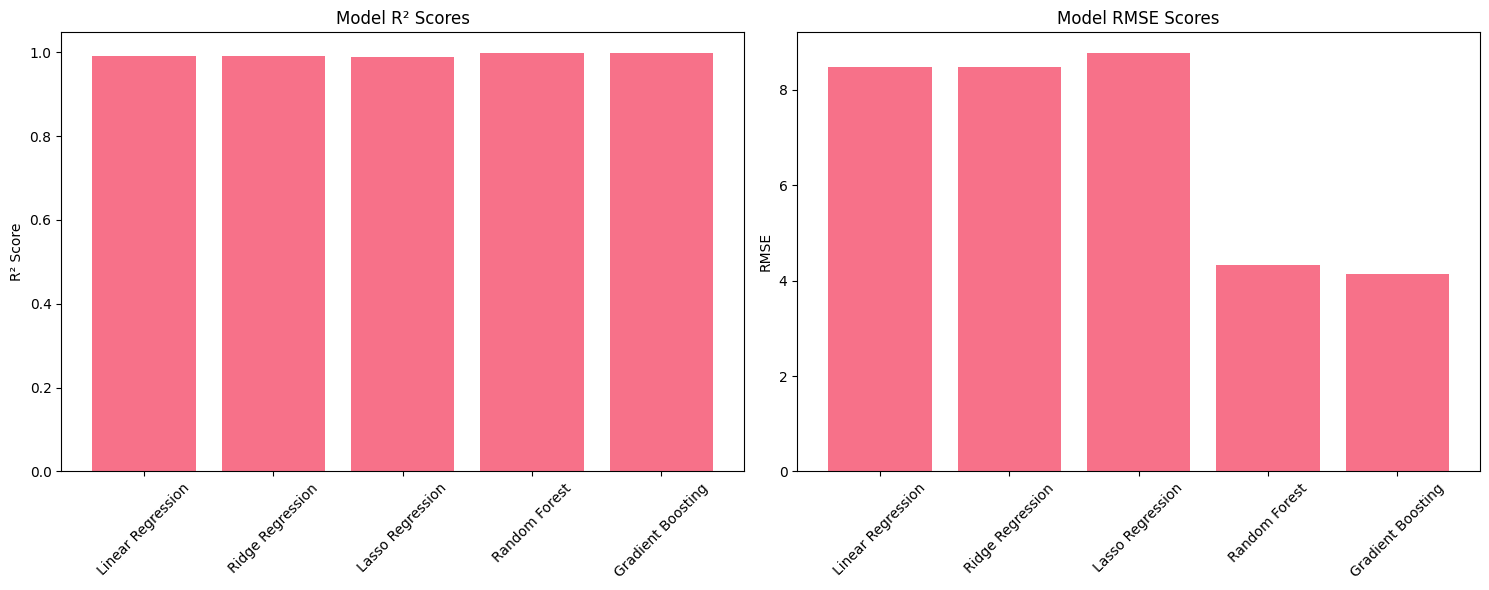

In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred); rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred); r2 = r2_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    results[name] = {'model': model, 'rmse': rmse, 'mae': mae, 'r2': r2, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f"RMSE: {rmse:.2f}"); print(f"MAE: {mae:.2f}"); print(f"R²: {r2:.3f}"); print(f"CV R²: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [results[n]['rmse'] for n in results],
    'MAE': [results[n]['mae'] for n in results],
    'R²': [results[n]['r2'] for n in results],
    'CV R² Mean': [results[n]['cv_mean'] for n in results],
    'CV R² Std': [results[n]['cv_std'] for n in results]
})
print("Model Performance Comparison:")
print(comparison_df)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.bar(comparison_df['Model'], comparison_df['R²']); ax1.set_ylabel('R² Score'); ax1.set_title('Model R² Scores'); ax1.tick_params(axis='x', rotation=45)
ax2.bar(comparison_df['Model'], comparison_df['RMSE']); ax2.set_ylabel('RMSE'); ax2.set_title('Model RMSE Scores'); ax2.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [14]:
def predict_cutoff(year, stroke, distance, final_type, gender='Men'):
    stroke_encoded = le_stroke.transform([stroke])[0]
    gender_encoded = le_gender.transform([gender])[0]
    final_type_encoded = le_final_type.transform([final_type])[0]
    features = np.array([[year, distance, stroke_encoded, gender_encoded, final_type_encoded, stroke_encoded * distance, year * distance, year ** 2]])
    return best_model.predict(features)[0]

examples = [(2024, 'Freestyle', 100, 'A', 'Men'), (2024, 'Backstroke', 200, 'B', 'Men'), (2024, 'Breaststroke', 100, 'C', 'Men'), (2024, 'Butterfly', 100, 'A', 'Men'), (2025, 'Freestyle', 100, 'A', 'Men')]
print("Example Predictions:\n", "="*50)
for year, stroke, distance, final_type, gender in examples:
    pred = predict_cutoff(year, stroke, distance, final_type, gender)
    minutes = int(pred // 60); seconds = pred % 60
    time_str = f"{minutes}:{seconds:05.2f}" if minutes>0 else f"{seconds:.2f}"
    print(f"{year} {gender} {distance} {stroke} {final_type} Final: {pred:.2f} seconds (Formatted: {time_str})")


Example Predictions:
2024 Men 100 Freestyle A Final: 45.60 seconds (Formatted: 45.60)
2024 Men 200 Backstroke B Final: 112.99 seconds (Formatted: 1:52.99)
2024 Men 100 Breaststroke C Final: 57.33 seconds (Formatted: 57.33)
2024 Men 100 Butterfly A Final: 49.30 seconds (Formatted: 49.30)
2025 Men 100 Freestyle A Final: 45.52 seconds (Formatted: 45.52)


Model Insights:


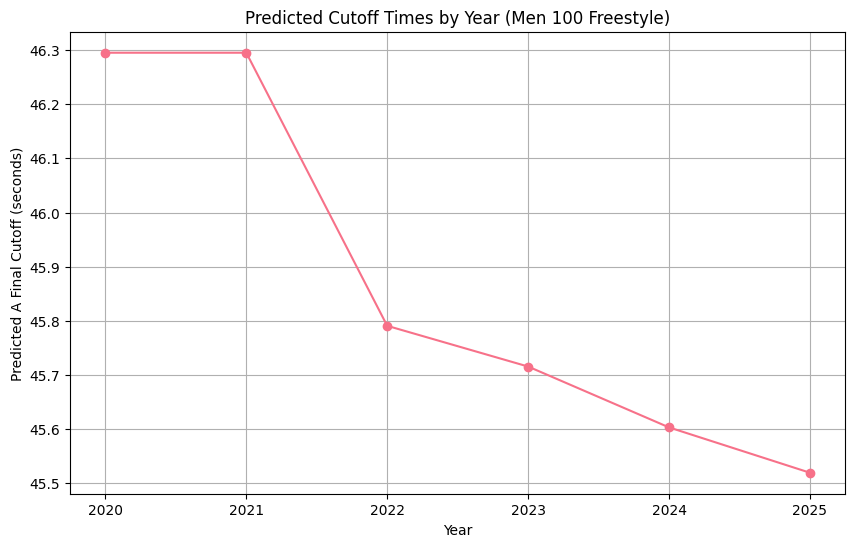

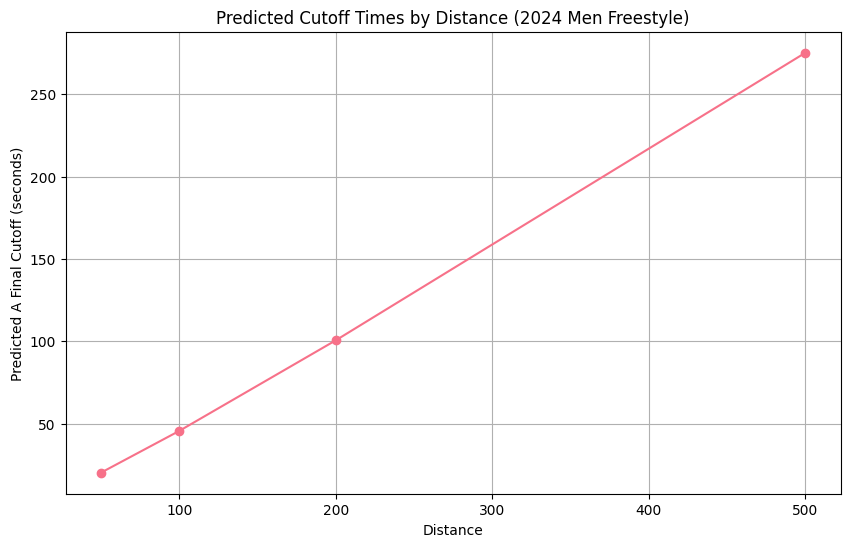

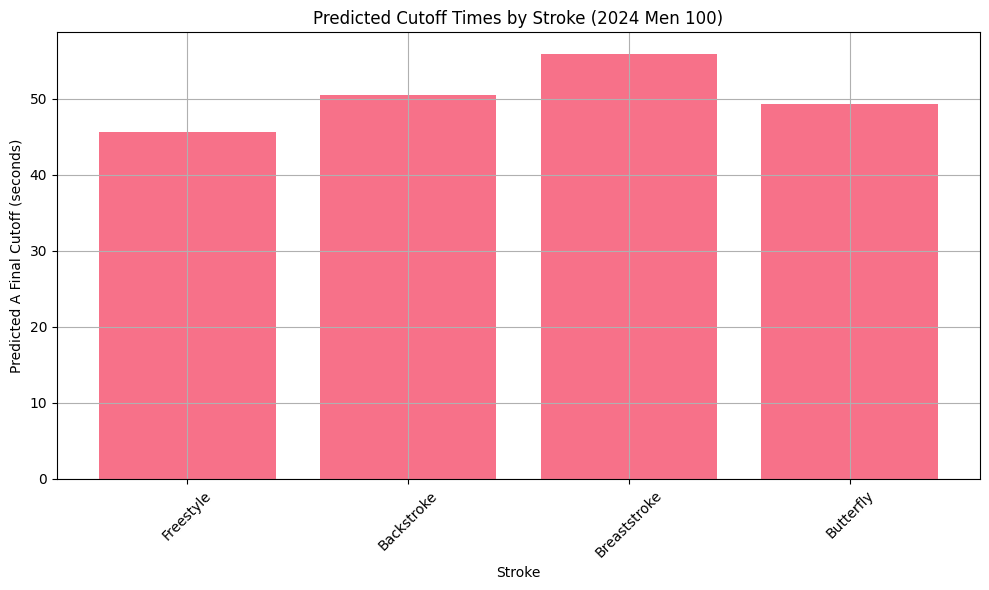

In [15]:
print("Model Insights:\n", "="*50)
years = range(2020, 2026)
y_preds = [predict_cutoff(y, 'Freestyle', 100, 'A', 'Men') for y in years]
plt.figure(figsize=(10, 6)); plt.plot(years, y_preds, marker='o'); plt.xlabel('Year'); plt.ylabel('Predicted A Final Cutoff (seconds)'); plt.title('Predicted Cutoff Times by Year (Men 100 Freestyle)'); plt.grid(True); plt.show()

dists = [50, 100, 200, 500]; d_preds = [predict_cutoff(2024, 'Freestyle', d, 'A', 'Men') for d in dists]
plt.figure(figsize=(10, 6)); plt.plot(dists, d_preds, marker='o'); plt.xlabel('Distance'); plt.ylabel('Predicted A Final Cutoff (seconds)'); plt.title('Predicted Cutoff Times by Distance (2024 Men Freestyle)'); plt.grid(True); plt.show()

strokes = ['Freestyle', 'Backstroke', 'Breaststroke', 'Butterfly']; s_preds = [predict_cutoff(2024, s, 100, 'A', 'Men') for s in strokes]
plt.figure(figsize=(10, 6)); plt.bar(strokes, s_preds); plt.xlabel('Stroke'); plt.ylabel('Predicted A Final Cutoff (seconds)'); plt.title('Predicted Cutoff Times by Stroke (2024 Men 100)'); plt.xticks(rotation=45); plt.grid(True); plt.tight_layout(); plt.show()
